# 2DAlphabet method in practice (toy example)

This notebook demonstrates, with a toy model, how the 2DAlphabet background estimate works in a boosted hadronic \( t\bar{t} \) analysis.

We will:

1. Define the \(m_t\) regions:
   - low sideband: \(25 < m_t < 105\) GeV
   - signal window: \(105 < m_t < 210\) GeV
   - high sideband: \(210 < m_t < 475\) GeV

2. Define PASS and FAIL categories:
   - FAIL: anti-tag region
   - PASS: signal-like tagging region

3. Create toy QCD in FAIL
4. Define a smooth transfer function \(R(m_t, m_{tt})\)
5. Predict QCD in PASS using
   \[
   N_{\mathrm{QCD}}^{\mathrm{PASS}} = R(m_t, m_{tt}) \times N_{\mathrm{QCD}}^{\mathrm{FAIL}}
   \]
6. Add SM \(t\bar t\) to create pseudo-data
7. Subtract SM \(t\bar t\) from data
8. Recover the QCD background estimate in the signal region

In [4]:
import dask
print(dask.__version__)
import dask.distributed
print(dask.distributed.__version__)

2025.3.0
2025.3.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

rng = np.random.default_rng(42)

In [2]:
# mt binning: top jet mass
mt_bins = np.array([25, 60, 85, 105, 130, 170, 210, 300, 475])

# mtt binning: ttbar invariant mass
mtt_bins = np.array([1000, 1400, 1800, 2200, 2800, 3500, 4500, 6000])

mt_centers = 0.5 * (mt_bins[:-1] + mt_bins[1:])
mtt_centers = 0.5 * (mtt_bins[:-1] + mtt_bins[1:])

MT, MTT = np.meshgrid(mt_centers, mtt_centers, indexing="ij")

print("mt bins:", mt_bins)
print("mtt bins:", mtt_bins)
print("2D histogram shape:", MT.shape)

mt bins: [ 25  60  85 105 130 170 210 300 475]
mtt bins: [1000 1400 1800 2200 2800 3500 4500 6000]
2D histogram shape: (8, 7)


In [3]:
# mt regions
low_mask = (MT >= 25) & (MT < 105)
sig_mask = (MT >= 105) & (MT < 210)
high_mask = (MT >= 210) & (MT < 475)

print("Low sideband bins:", np.sum(low_mask))
print("Signal window bins:", np.sum(sig_mask))
print("High sideband bins:", np.sum(high_mask))

Low sideband bins: 21
Signal window bins: 21
High sideband bins: 14


In [4]:
# A smooth toy QCD shape in FAIL:
# decreases with mt and mtt, but not perfectly factorized

qcd_fail_expectation = (
    2.5e5
    * np.exp(-(MT - 25) / 120.0)
    * np.exp(-(MTT - 1000) / 1400.0)
    * (1.0 + 0.08 * np.sin(MT / 40.0))
    * (1.0 + 0.05 * np.cos(MTT / 700.0))
)

qcd_fail = rng.poisson(qcd_fail_expectation)

qcd_fail.shape

(8, 7)

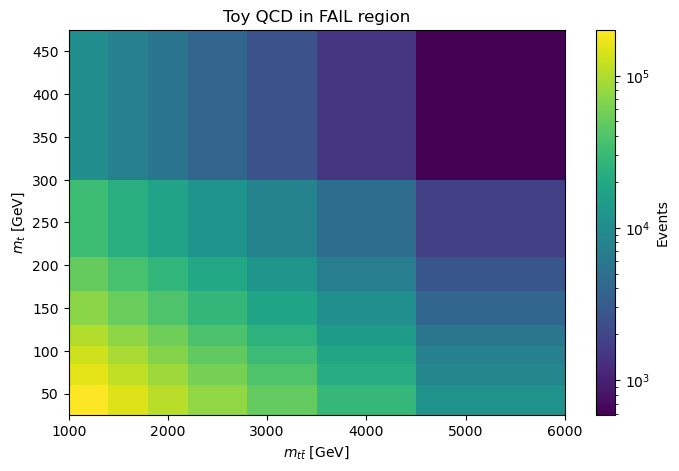

In [5]:
plt.figure(figsize=(8, 5))
plt.pcolormesh(mtt_bins, mt_bins, qcd_fail, norm=LogNorm())
plt.xlabel(r"$m_{t\bar{t}}$ [GeV]")
plt.ylabel(r"$m_t$ [GeV]")
plt.title("Toy QCD in FAIL region")
cbar = plt.colorbar()
cbar.set_label("Events")
plt.show()

In [6]:
# A toy pass/fail ratio, analogous to the analytic transfer function in 2DAlphabet
# Keep it smooth and positive

R_true = (
    0.06
    * (1.0 + 0.0015 * (MT - 150))
    * (1.0 + 0.00018 * (MTT - 2000))
)

# Ensure positivity
R_true = np.clip(R_true, 0.01, None)

print("R min =", R_true.min())
print("R max =", R_true.max())

R min = 0.0430782
R max = 0.12897937499999998


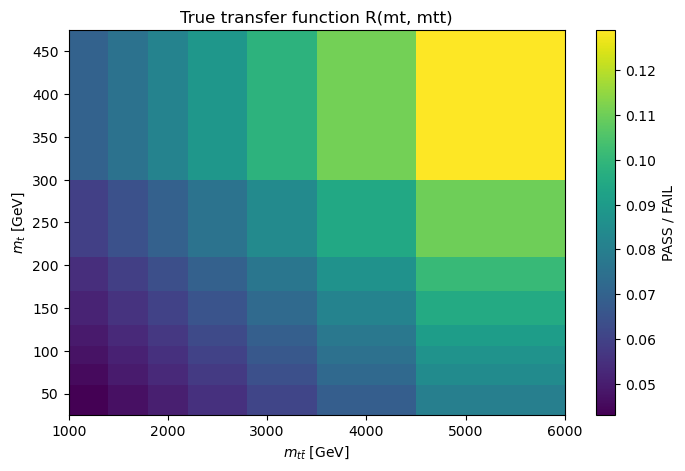

In [7]:
plt.figure(figsize=(8, 5))
plt.pcolormesh(mtt_bins, mt_bins, R_true)
plt.xlabel(r"$m_{t\bar{t}}$ [GeV]")
plt.ylabel(r"$m_t$ [GeV]")
plt.title("True transfer function R(mt, mtt)")
cbar = plt.colorbar()
cbar.set_label("PASS / FAIL")
plt.show()

In [8]:
qcd_pass_expectation = R_true * qcd_fail_expectation
qcd_pass = rng.poisson(qcd_pass_expectation)

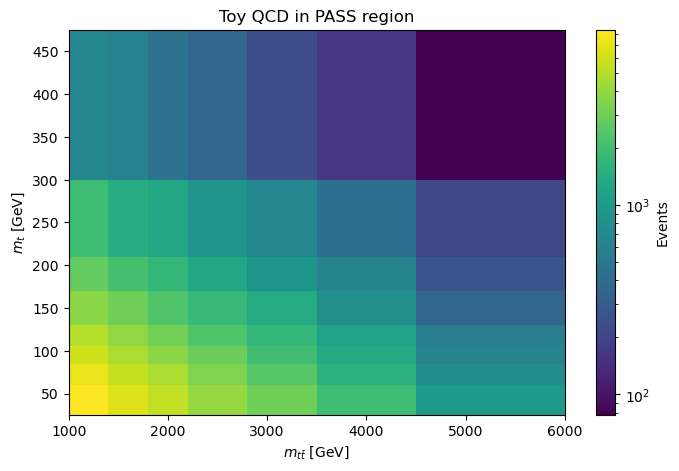

In [9]:
plt.figure(figsize=(8, 5))
plt.pcolormesh(mtt_bins, mt_bins, qcd_pass, norm=LogNorm())
plt.xlabel(r"$m_{t\bar{t}}$ [GeV]")
plt.ylabel(r"$m_t$ [GeV]")
plt.title("Toy QCD in PASS region")
cbar = plt.colorbar()
cbar.set_label("Events")
plt.show()

In [10]:
# SM ttbar is more localized around the top mass window
ttbar_fail_expectation = (
    2500
    * np.exp(-0.5 * ((MT - 155) / 45.0) ** 2)
    * np.exp(-(MTT - 1200) / 1800.0)
)

ttbar_pass_expectation = (
    9000
    * np.exp(-0.5 * ((MT - 155) / 35.0) ** 2)
    * np.exp(-(MTT - 1200) / 1700.0)
)

ttbar_fail = rng.poisson(np.clip(ttbar_fail_expectation, 0, None))
ttbar_pass = rng.poisson(np.clip(ttbar_pass_expectation, 0, None))

In [11]:
# Data = QCD + SM ttbar
data_fail = rng.poisson(qcd_fail + ttbar_fail)
data_pass = rng.poisson(qcd_pass + ttbar_pass)

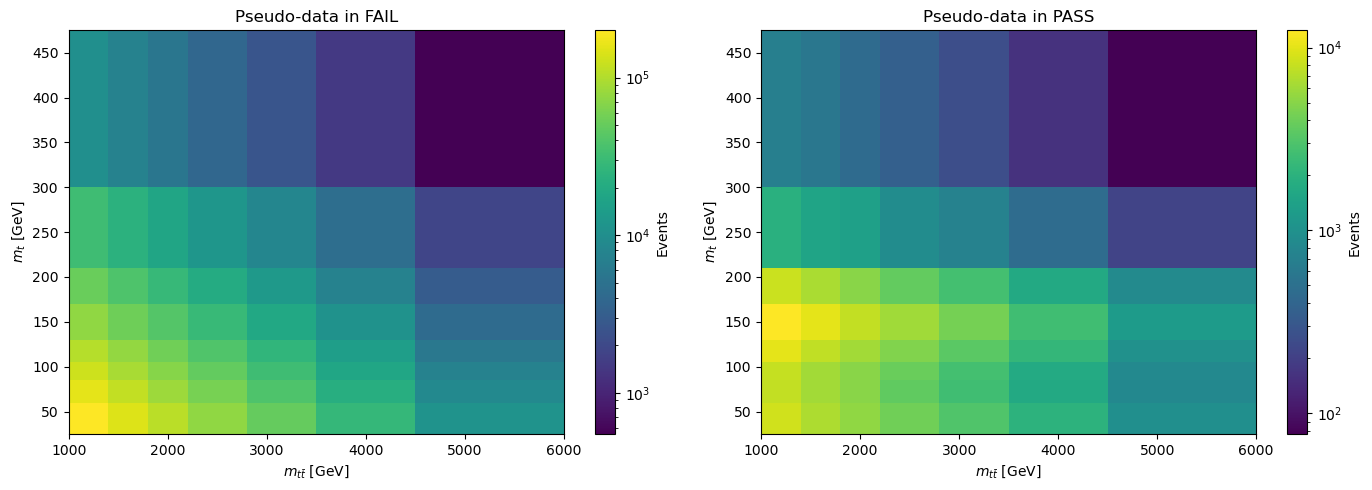

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].pcolormesh(mtt_bins, mt_bins, data_fail, norm=LogNorm())
axes[0].set_title("Pseudo-data in FAIL")
axes[0].set_xlabel(r"$m_{t\bar{t}}$ [GeV]")
axes[0].set_ylabel(r"$m_t$ [GeV]")
cbar0 = plt.colorbar(im0, ax=axes[0])
cbar0.set_label("Events")

im1 = axes[1].pcolormesh(mtt_bins, mt_bins, data_pass, norm=LogNorm())
axes[1].set_title("Pseudo-data in PASS")
axes[1].set_xlabel(r"$m_{t\bar{t}}$ [GeV]")
axes[1].set_ylabel(r"$m_t$ [GeV]")
cbar1 = plt.colorbar(im1, ax=axes[1])
cbar1.set_label("Events")

plt.tight_layout()
plt.show()

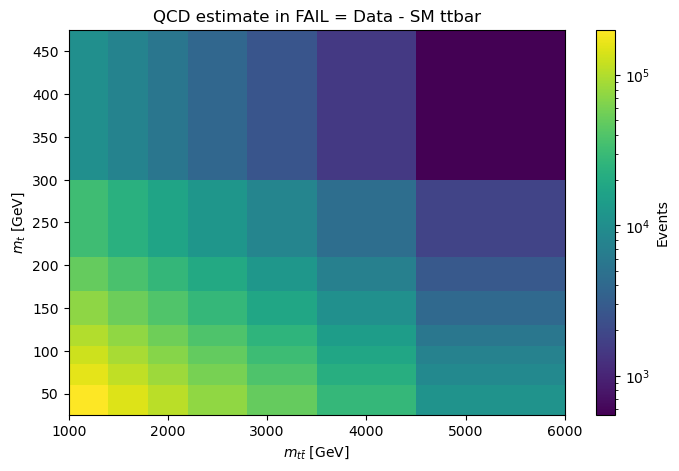

In [13]:
# In the analysis, the QCD in FAIL is taken as Data - SM ttbar
qcd_fail_from_data = data_fail - ttbar_fail

# avoid negative bins in this toy example
qcd_fail_from_data = np.clip(qcd_fail_from_data, 0, None)

plt.figure(figsize=(8, 5))
plt.pcolormesh(mtt_bins, mt_bins, qcd_fail_from_data, norm=LogNorm())
plt.xlabel(r"$m_{t\bar{t}}$ [GeV]")
plt.ylabel(r"$m_t$ [GeV]")
plt.title("QCD estimate in FAIL = Data - SM ttbar")
cbar = plt.colorbar()
cbar.set_label("Events")
plt.show()

In [14]:
qcd_pass_pred = R_true * qcd_fail_from_data

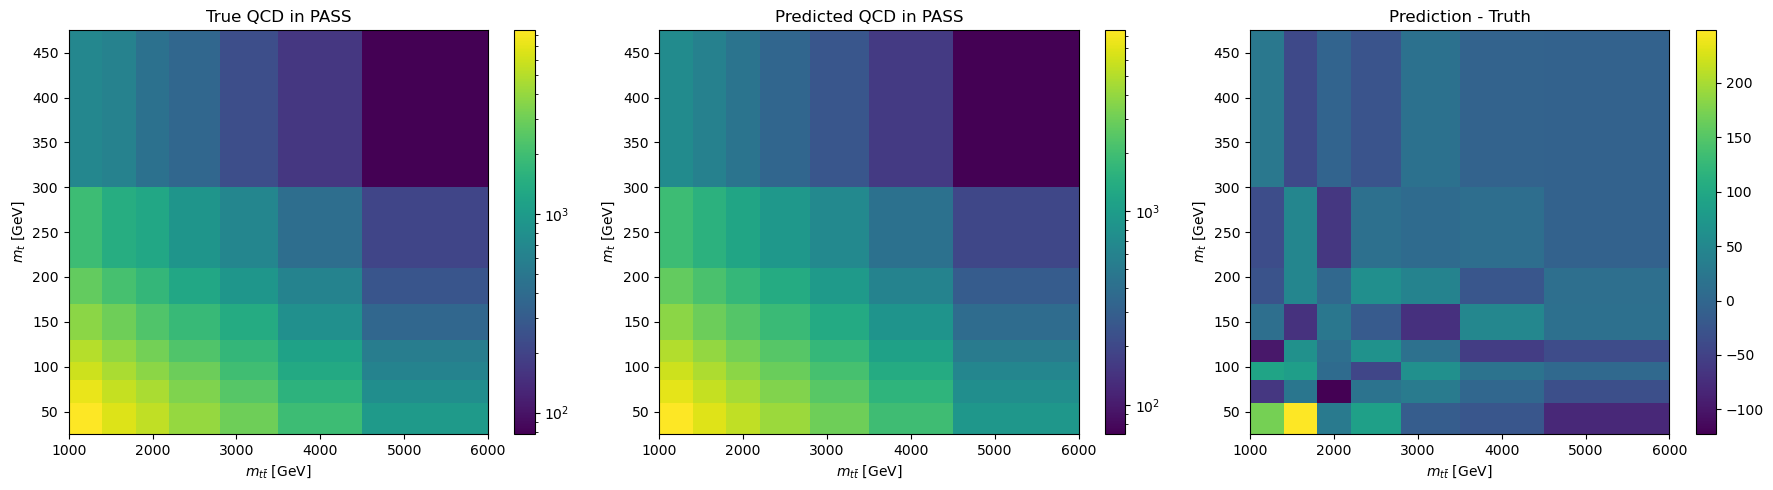

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].pcolormesh(mtt_bins, mt_bins, qcd_pass, norm=LogNorm())
axes[0].set_title("True QCD in PASS")
axes[0].set_xlabel(r"$m_{t\bar{t}}$ [GeV]")
axes[0].set_ylabel(r"$m_t$ [GeV]")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(mtt_bins, mt_bins, qcd_pass_pred, norm=LogNorm())
axes[1].set_title("Predicted QCD in PASS")
axes[1].set_xlabel(r"$m_{t\bar{t}}$ [GeV]")
axes[1].set_ylabel(r"$m_t$ [GeV]")
plt.colorbar(im1, ax=axes[1])

diff = qcd_pass_pred - qcd_pass
im2 = axes[2].pcolormesh(mtt_bins, mt_bins, diff)
axes[2].set_title("Prediction - Truth")
axes[2].set_xlabel(r"$m_{t\bar{t}}$ [GeV]")
axes[2].set_ylabel(r"$m_t$ [GeV]")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [16]:
# Region D corresponds to PASS + signal mt window
true_D = np.where(sig_mask, qcd_pass, 0.0)
pred_D = np.where(sig_mask, qcd_pass_pred, 0.0)

print("True QCD yield in D =", true_D.sum())
print("Predicted QCD yield in D =", pred_D.sum())
print("Fractional difference =", (pred_D.sum() - true_D.sum()) / true_D.sum())

True QCD yield in D = 40858.0
Predicted QCD yield in D = 40868.78416552501
Fractional difference = 0.0002639425699987414


In [17]:
# Region C = FAIL + signal window
C_region = np.where(sig_mask, qcd_fail_from_data, 0.0)
D_from_C = R_true * C_region

print("Yield in control region C =", C_region.sum())
print("Predicted QCD yield in D = R x C =", D_from_C.sum())

Yield in control region C = 693130.0
Predicted QCD yield in D = R x C = 40868.78416552501


In [18]:
# Project over mt signal window to get mtt distributions
true_D_mtt = qcd_pass[sig_mask].reshape(np.sum(sig_mask, axis=0)[0], -1) if False else qcd_pass[sig_mask]
pred_D_mtt = qcd_pass_pred[sig_mask]
data_pass_sig_mtt = data_pass[sig_mask]
ttbar_pass_sig_mtt = ttbar_pass[sig_mask]

# easier way: sum over mt bins inside signal mask
mt_sig_indices = np.where((mt_centers >= 105) & (mt_centers < 210))[0]

true_qcd_mtt = qcd_pass[mt_sig_indices, :].sum(axis=0)
pred_qcd_mtt = qcd_pass_pred[mt_sig_indices, :].sum(axis=0)
data_mtt = data_pass[mt_sig_indices, :].sum(axis=0)
ttbar_mtt = ttbar_pass[mt_sig_indices, :].sum(axis=0)

mtt_plot_centers = mtt_centers
mtt_plot_widths = np.diff(mtt_bins)

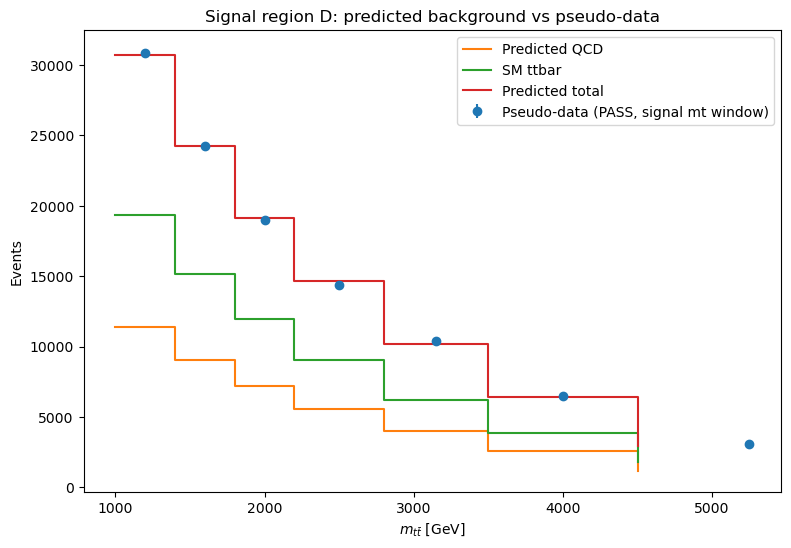

In [19]:
plt.figure(figsize=(9, 6))

plt.errorbar(
    mtt_plot_centers,
    data_mtt,
    yerr=np.sqrt(np.maximum(data_mtt, 1)),
    fmt="o",
    label="Pseudo-data (PASS, signal mt window)"
)

plt.step(mtt_bins[:-1], pred_qcd_mtt, where="post", label="Predicted QCD")
plt.step(mtt_bins[:-1], ttbar_mtt, where="post", label="SM ttbar")
plt.step(mtt_bins[:-1], pred_qcd_mtt + ttbar_mtt, where="post", label="Predicted total")

plt.xlabel(r"$m_{t\bar{t}}$ [GeV]")
plt.ylabel("Events")
plt.title("Signal region D: predicted background vs pseudo-data")
plt.legend()
plt.show()

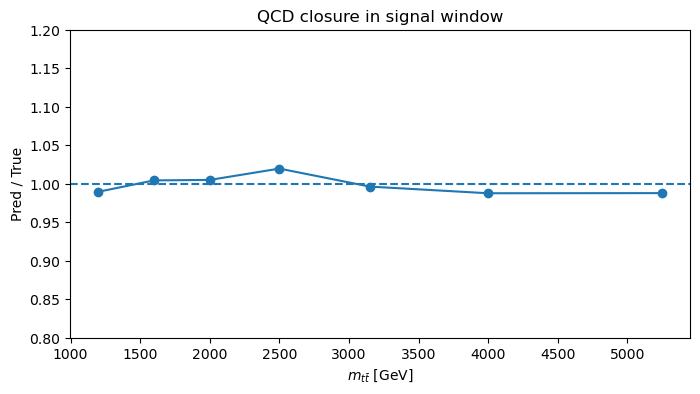

In [20]:
ratio = np.divide(
    pred_qcd_mtt,
    true_qcd_mtt,
    out=np.zeros_like(pred_qcd_mtt, dtype=float),
    where=true_qcd_mtt > 0
)

plt.figure(figsize=(8, 4))
plt.axhline(1.0, linestyle="--")
plt.plot(mtt_plot_centers, ratio, "o-")
plt.xlabel(r"$m_{t\bar{t}}$ [GeV]")
plt.ylabel("Pred / True")
plt.title("QCD closure in signal window")
plt.ylim(0.8, 1.2)
plt.show()